# 2D Deep Learning Models for Impact Echo Classification

This notebook implements the Transfer Learning (TL) approach for AlexNet.

AlexNet (Transfer Learning)
Instead of training the network from scratch, we leverage a model pre-trained on the ImageNet dataset. 
The convolutional feature extractors are "frozen" (their weights are not updated), and only the final 
fully connected layers are modified and trained to classify our Impact Echo spectrograms (Sound vs. Defected).

* **Architecture:** AlexNet (Pre-trained `IMAGENET1K_V1` weights)
* **Input Size:** 227 x 227 x 3 (Normalized to ImageNet standards)
* **Optimizer:** SGDM
* **Batch Size:** 50
* **Max Epochs:** 40
* **Learning Rate:** 1e-3

In [16]:
import os
import time
import numpy as np
import pandas as pd
from scipy import signal

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms

from sklearn.metrics import confusion_matrix

# Hardware setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("=== Hardware Check ===")
if device.type == 'cuda':
    print(f"SUCCESS: GPU Detected - {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True 
else:
    print("WARNING: CUDA not detected by PyTorch.")
print("======================\n")

=== Hardware Check ===
SUCCESS: GPU Detected - NVIDIA RTX 5000 Ada Generation Laptop GPU



In [17]:
base_dir = r"C:\Users\kairen.shen.ctr\My Drive\4 IE reproduce\testing data"

all_filepaths = []
all_labels = []
all_slab_ids = []

for slab_id in range(1, 9):
    slab_folder = os.path.join(base_dir, f"Slab{slab_id}")
    
    # Process Defected (Class 1)
    d_folder = os.path.join(slab_folder, "D")
    if os.path.exists(d_folder):
        for file in os.listdir(d_folder):
            if file.endswith(".txt"):
                all_filepaths.append(os.path.join(d_folder, file))
                all_labels.append(1)
                all_slab_ids.append(slab_id)
                
    # Process Sound (Class 0)
    s_folder = os.path.join(slab_folder, "S")
    if os.path.exists(s_folder):
        for file in os.listdir(s_folder):
            if file.endswith(".txt"):
                all_filepaths.append(os.path.join(s_folder, file))
                all_labels.append(0)
                all_slab_ids.append(slab_id)

all_filepaths = np.array(all_filepaths)
all_labels = np.array(all_labels)
all_slab_ids = np.array(all_slab_ids)

print(f"Total files found: {len(all_filepaths)}")
print(f"Total Sound (0): {sum(all_labels == 0)}, Total Defected (1): {sum(all_labels == 1)}")

Total files found: 2016
Total Sound (0): 1504, Total Defected (1): 512


## Transfer Learning Dataset & Model
Because we are using pre-trained weights, the input images **must** be normalized using ImageNet's specific mean and standard deviation. We define this in the `SpectrogramDataset` class.

In [18]:
class SpectrogramDataset(Dataset):
    def __init__(self, file_paths, labels):
        self.file_paths = file_paths
        self.labels = labels
        
        # ImageNet standardization values
        self.normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        # 1. Load Data & Remove DC Offset
        df = pd.read_csv(self.file_paths[idx], sep=r'\s+', header=None, names=['Time', 'Voltage'])
        voltage = df['Voltage'].values.astype(np.float32)
        voltage = voltage - np.mean(voltage)
        
        # 2. Generate Spectrogram via STFT
        f, t, Zxx = signal.stft(voltage, fs=200000, nperseg=128, noverlap=64)
        spec_mag = np.abs(Zxx)
        
        # Convert to log scale (dB)
        spec_log = 10 * np.log10(spec_mag + 1e-8)
        
        # 3. Normalize to [0, 1] range first
        spec_norm = (spec_log - np.min(spec_log)) / (np.max(spec_log) - np.min(spec_log) + 1e-8)
        
        # 4. Format to AlexNet specs: (3, 227, 227)
        spec_tensor = torch.tensor(spec_norm, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
        resized_spec = F.interpolate(spec_tensor, size=(227, 227), mode='bilinear', align_corners=False)
        
        # Duplicate to 3 channels
        rgb_spec = resized_spec.squeeze(0).repeat(3, 1, 1)
        
        # CRITICAL FOR TL: Apply ImageNet Normalization
        final_spec = self.normalize(rgb_spec)
        
        label_tensor = torch.tensor(self.labels[idx], dtype=torch.long)
        return final_spec, label_tensor

def get_alexnet_tl(num_classes=2):
    model = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)
    
    # 1. Freeze the convolutional feature extractors (features block)
    for param in model.features.parameters():
        param.requires_grad = False
        
    # 2. Unfreeze the 3 fully connected layers (classifier block)
    for param in model.classifier.parameters():
        param.requires_grad = True
        
    # 3. Replace the final layer (this automatically has requires_grad=True)
    model.classifier[6] = nn.Linear(4096, num_classes)
    
    # 4. Explicitly initialize the new weights
    nn.init.xavier_normal_(model.classifier[6].weight)
    nn.init.constant_(model.classifier[6].bias, 0)
    
    return model

In [20]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
from sklearn.metrics import confusion_matrix

# =========================================================
# 1. Hardware Setup & Data Aggregation
# =========================================================
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

base_dir = r"C:\Users\kairen.shen.ctr\My Drive\4 IE reproduce\testing data"
all_filepaths = []
all_labels = []
all_slab_ids = []

# Map all file paths, labels, and slab assignments
for slab_id in range(1, 9):
    slab_folder = os.path.join(base_dir, f"Slab{slab_id}")
    
    d_folder = os.path.join(slab_folder, "D")
    if os.path.exists(d_folder):
        for file in os.listdir(d_folder):
            if file.endswith(".txt"):
                all_filepaths.append(os.path.join(d_folder, file))
                all_labels.append(1)
                all_slab_ids.append(slab_id)
                
    s_folder = os.path.join(slab_folder, "S")
    if os.path.exists(s_folder):
        for file in os.listdir(s_folder):
            if file.endswith(".txt"):
                all_filepaths.append(os.path.join(s_folder, file))
                all_labels.append(0)
                all_slab_ids.append(slab_id)

all_filepaths = np.array(all_filepaths)
all_labels = np.array(all_labels)
all_slab_ids = np.array(all_slab_ids)

# =========================================================
# 2. Dataset & Model Definitions
# =========================================================
class SpectrogramDataset(Dataset):
    def __init__(self, file_paths, labels):
        self.file_paths = file_paths
        self.labels = labels
        # ImageNet standardization values
        self.normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        df = pd.read_csv(self.file_paths[idx], sep=r'\s+', header=None, names=['Time', 'Voltage'])
        voltage = df['Voltage'].values.astype(np.float32)
        voltage = voltage - np.mean(voltage)
        
        f, t, Zxx = signal.stft(voltage, fs=200000, nperseg=128, noverlap=64)
        spec_mag = np.abs(Zxx)
        spec_log = 10 * np.log10(spec_mag + 1e-8)
        spec_norm = (spec_log - np.min(spec_log)) / (np.max(spec_log) - np.min(spec_log) + 1e-8)
        
        spec_tensor = torch.tensor(spec_norm, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
        resized_spec = F.interpolate(spec_tensor, size=(227, 227), mode='bilinear', align_corners=False)
        rgb_spec = resized_spec.squeeze(0).repeat(3, 1, 1)
        final_spec = self.normalize(rgb_spec)
        
        label_tensor = torch.tensor(self.labels[idx], dtype=torch.long)
        return final_spec, label_tensor


def get_alexnet_tl(num_classes=2):
    model = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)
    
    # Freeze the pretrained feature extractor but train the classifier head
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.classifier.parameters():
        param.requires_grad = True
    
    model.classifier[6] = nn.Linear(4096, num_classes)
    nn.init.xavier_normal_(model.classifier[6].weight)
    nn.init.constant_(model.classifier[6].bias, 0)
    
    return model

# =========================================================
# 3. Training Protocol (AlexNet TL)
# =========================================================
# Hyperparameters tuned for smoother loss reduction
EPOCHS = 40
BATCH_SIZE = 50
LR = 1e-4
MOMENTUM = 0.9
WEIGHT_DECAY = 1e-4

alexnet_tl_metrics = {'ACC': [], 'TPR': [], 'TNR': [], 'F1': []}
iteration_accuracies = {slab: [] for slab in range(1, 9)}
total_start_time = time.time()

for test_slab in range(1, 9):
    print(f"--- Training AlexNet (TL): Holding out Slab {test_slab} for Testing ---")
    fold_start_time = time.time()
    
    train_idx = np.where(all_slab_ids != test_slab)[0]
    test_idx = np.where(all_slab_ids == test_slab)[0]
    
    train_files, train_labels = all_filepaths[train_idx], all_labels[train_idx]
    test_files, test_labels = all_filepaths[test_idx], all_labels[test_idx]
    
    train_dataset = SpectrogramDataset(train_files, train_labels)
    test_dataset = SpectrogramDataset(test_files, test_labels)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
    
    model = get_alexnet_tl().to(device)
    
    num_sound = np.sum(train_labels == 0)
    num_defected = np.sum(train_labels == 1)
    weight_ratio = num_sound / num_defected
    class_weights = torch.tensor([1.0, weight_ratio], dtype=torch.float32).to(device)
    
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
    
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.AdamW(trainable_params, lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    
    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0
        
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device, non_blocking=True), targets.to(device, non_blocking=True)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            
            torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=5.0)
            optimizer.step()
            running_loss += loss.item()
            
            _, preds = torch.max(outputs, 1)
            correct = (preds == targets).sum().item()
            batch_acc = (correct / targets.size(0)) * 100.0  
            iteration_accuracies[test_slab].append(batch_acc)
            
        epoch_loss = running_loss / len(train_loader)
        scheduler.step()
        
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  Epoch [{epoch+1:02d}/{EPOCHS}] - Loss: {epoch_loss:.4f}")
            
    model.eval()
    all_preds = []
    all_targs = []
    
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device, non_blocking=True), targets.to(device, non_blocking=True)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_targs.extend(targets.cpu().numpy())
            
    tn, fp, fn, tp = confusion_matrix(all_targs, all_preds).ravel()
    
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0  
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0.0  
    acc = (tp + tn) / (tp + tn + fp + fn)           
    f1 = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0.0 
    
    fold_time = time.time() - fold_start_time
    print(f"  > Test Slab {test_slab} Results - ACC: {acc:.2f} | TPR: {tpr:.2f} | TNR: {tnr:.2f} | F1: {f1:.2f}")
    print(f"  > Fold completed in {fold_time:.1f} seconds.\n")
    
    alexnet_tl_metrics['ACC'].append(acc)
    alexnet_tl_metrics['TPR'].append(tpr)
    alexnet_tl_metrics['TNR'].append(tnr)
    alexnet_tl_metrics['F1'].append(f1)

total_time = time.time() - total_start_time

# =========================================================
# 4. Output Summary Metrics
# =========================================================
print("=============================================")
print(f"Total AlexNet (TL) Training Time: {total_time/60:.2f} minutes")
print("=== Overall AlexNet (TL) Performance Metrics ===")

for metric, values in alexnet_tl_metrics.items():
    mean_val = np.mean(values)
    std_val = np.std(values)
    cov_val = std_val / mean_val if mean_val > 0 else 0.0
    max_val = np.max(values)
    min_val = np.min(values)
    
    print(f"{metric} - Mean: {mean_val:.2f} | COV: {cov_val:.2f} | Max: {max_val:.2f} | Min: {min_val:.2f}")


--- Training AlexNet (TL): Holding out Slab 1 for Testing ---
  Epoch [01/40] - Loss: 0.7960
  Epoch [05/40] - Loss: 0.5510
  Epoch [10/40] - Loss: 0.4780
  Epoch [15/40] - Loss: 0.4158
  Epoch [20/40] - Loss: 0.3769
  Epoch [25/40] - Loss: 0.3596
  Epoch [30/40] - Loss: 0.3367
  Epoch [35/40] - Loss: 0.3307
  Epoch [40/40] - Loss: 0.3333
  > Test Slab 1 Results - ACC: 0.85 | TPR: 0.66 | TNR: 0.91 | F1: 0.69
  > Fold completed in 315.2 seconds.

--- Training AlexNet (TL): Holding out Slab 2 for Testing ---
  Epoch [01/40] - Loss: 0.7935
  Epoch [05/40] - Loss: 0.5503
  Epoch [10/40] - Loss: 0.4658
  Epoch [15/40] - Loss: 0.4174
  Epoch [20/40] - Loss: 0.3694
  Epoch [25/40] - Loss: 0.3489
  Epoch [30/40] - Loss: 0.3362
  Epoch [35/40] - Loss: 0.3253
  Epoch [40/40] - Loss: 0.3291
  > Test Slab 2 Results - ACC: 0.85 | TPR: 0.69 | TNR: 0.90 | F1: 0.70
  > Fold completed in 308.3 seconds.

--- Training AlexNet (TL): Holding out Slab 3 for Testing ---
  Epoch [01/40] - Loss: 0.7795
  Epoch


Generating Accuracy vs Iteration plot for AlexNet (TL)...


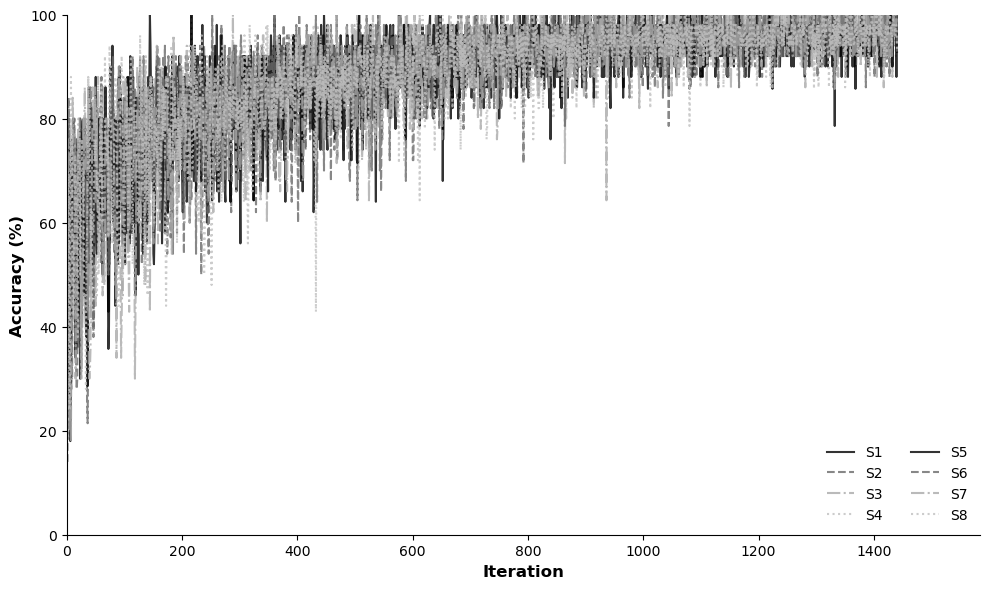

Plot saved successfully as 'alexnet_tl_accuracy_vs_iteration.png'.


In [21]:
# =========================================================
# 5. Plotting Accuracy vs Iteration
# =========================================================
print("\nGenerating Accuracy vs Iteration plot for AlexNet (TL)...")
fig, ax = plt.subplots(figsize=(10, 6))

line_styles = ['-', '--', '-.', ':', '-', '--', '-.', ':']
colors = ['black', 'dimgray', 'darkgray', 'silver', 'black', 'dimgray', 'darkgray', 'silver']

for slab_id in range(1, 9):
    acc_data = iteration_accuracies[slab_id]
    iterations = range(1, len(acc_data) + 1)
    
    ax.plot(iterations, acc_data, label=f'S{slab_id}', 
             linestyle=line_styles[slab_id-1], color=colors[slab_id-1], alpha=0.8, linewidth=1.5)

ax.set_xlabel('Iteration', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_ylim(0, 100)

# Add some padding to the x-axis for the legend to breathe
ax.set_xlim(0, len(iteration_accuracies[1]) * 1.1) 

# Clean up axes for a publication-ready look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(loc='lower right', frameon=False, fontsize=10, ncol=2)

plt.tight_layout()
plt.savefig('alexnet_tl_accuracy_vs_iteration.png', dpi=300, bbox_inches='tight')
plt.show()
print("Plot saved successfully as 'alexnet_tl_accuracy_vs_iteration.png'.")